# AOMIC-ID1000 - Tabular Phenotype Exploration

Prediction target: **total intelligence** (`IST_intelligence_total`, IST 2000-R composite).
This notebook profiles the self-report phenotype that feeds the lower complexity tiers:
target distribution, missingness, feature-feature correlation structure, and which
features actually track intelligence. All values shown here are the raw dataset values
(before the ontology projection and z-scoring done by the ingestion pipeline).

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="notebook")
ROOT = Path.cwd().parent
df = pd.read_csv(ROOT / "dataset" / "participants.tsv", sep="\t", na_values=["n/a","N/A",""])
manifest = json.load(open(ROOT / "ontology" / "feature_manifest.json"))
target = manifest["target"]["column"]
print("participants:", len(df), "| target:", target)

participants: 928 | target: IST_intelligence_total


## Target: total intelligence and its subscales

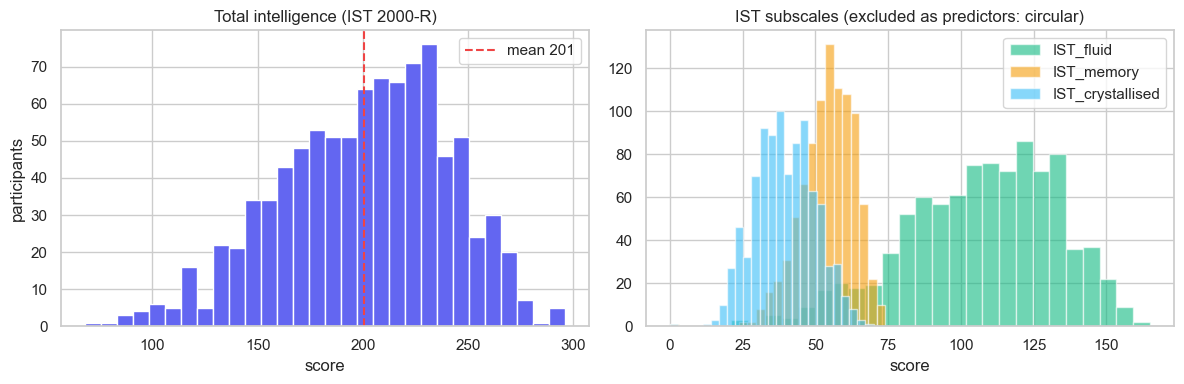

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
t = pd.to_numeric(df[target], errors="coerce").dropna()
ax[0].hist(t, bins=30, color="#6366f1", edgecolor="white")
ax[0].axvline(t.mean(), color="#ef4444", ls="--", label=f"mean {t.mean():.0f}")
ax[0].set(title="Total intelligence (IST 2000-R)", xlabel="score", ylabel="participants"); ax[0].legend()
for c, col in zip(["#10b981","#f59e0b","#38bdf8"], ["IST_fluid","IST_memory","IST_crystallised"]):
    ax[1].hist(pd.to_numeric(df[col], errors="coerce").dropna(), bins=25, alpha=0.6, label=col, color=c)
ax[1].set(title="IST subscales (excluded as predictors: circular)", xlabel="score"); ax[1].legend()
plt.tight_layout(); plt.show()

The three IST subscales sum to the total, so they are excluded from the predictors.
Everything the tiers use is *non-cognitive*: personality, motivation, affect,
demographics, identity, and later brain structure and connectivity.

## Predictor groups and missingness

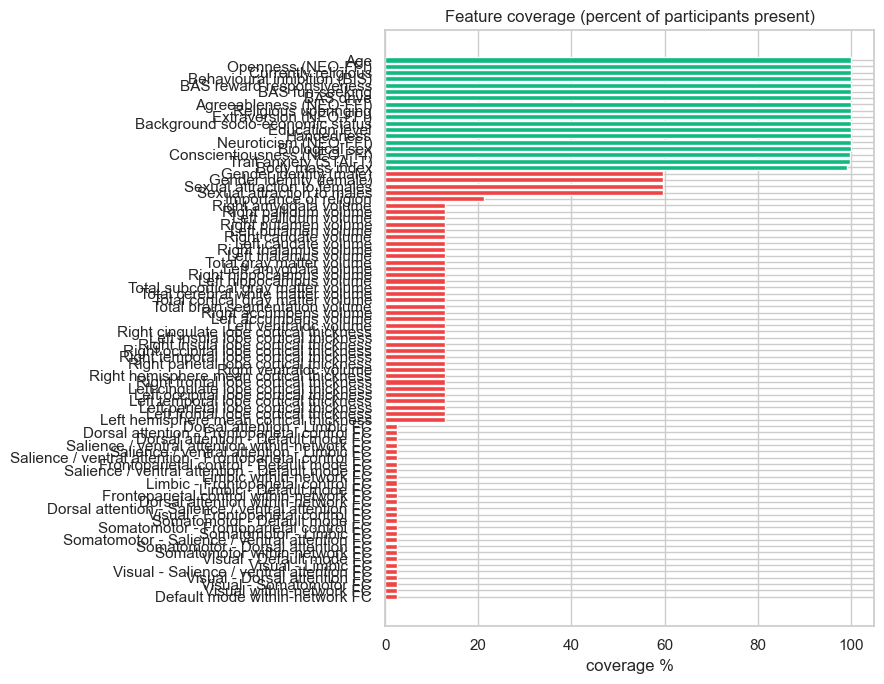

Sparsest features: fc_default_within, fc_vis_within, fc_vis_sommot, fc_vis_dorsattn


In [3]:
preds = pd.DataFrame(manifest["predictors"])
groups = preds.groupby("column").first()
order = preds.sort_values("coverage_pct")
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#ef4444" if c < 70 else "#f59e0b" if c < 95 else "#10b981" for c in order["coverage_pct"]]
ax.barh(order["label"], order["coverage_pct"], color=colors)
ax.set(title="Feature coverage (percent of participants present)", xlabel="coverage %")
plt.tight_layout(); plt.show()
print("Sparsest features:", ", ".join(order.head(4)["column"]))

Missingness varies a lot: personality and demographics are near-complete, the
sexual/gender identity ratings are ~60% present, and `religious_importance` is
only ~21% present. The ingestion pipeline encodes missing leaves explicitly, so the
engine sees which evidence is absent rather than silently imputed.

## Feature-feature correlation structure

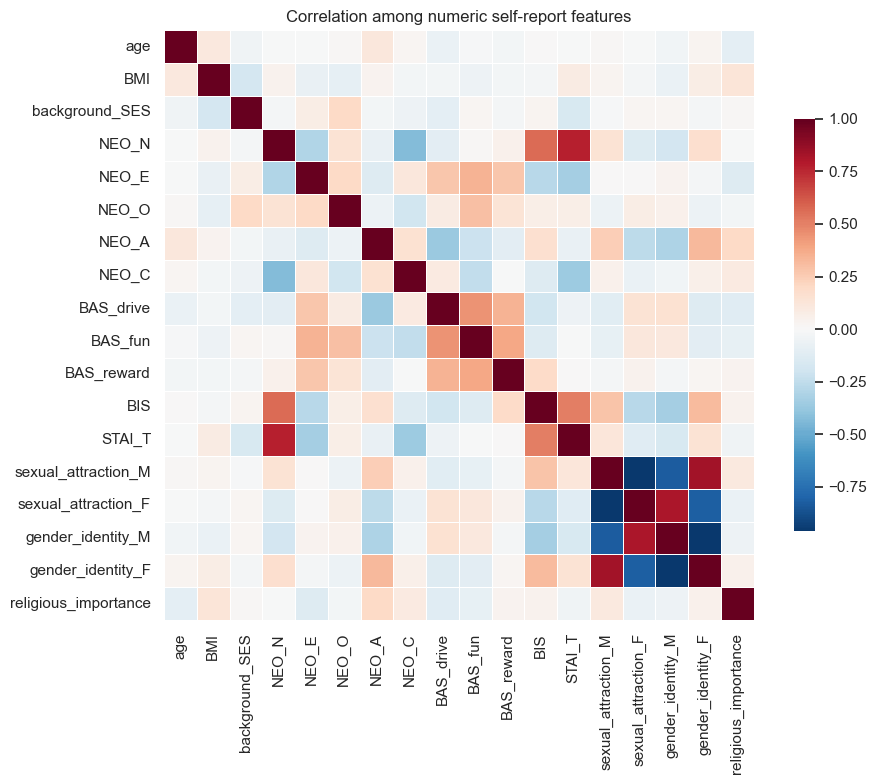

In [4]:
# Tabular self-report features only (brain modalities are covered in notebook 2).
num_cols = [p["column"] for p in manifest["predictors"]
            if p["stat_type"] == "numeric" and p["column"] in df.columns
            and not p["column"].startswith(("fs_", "fc_"))]
corr = df[num_cols].apply(pd.to_numeric, errors="coerce").corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, cmap="RdBu_r", center=0, square=True, linewidths=.5,
            cbar_kws={"shrink": .7}, ax=ax)
ax.set_title("Correlation among numeric self-report features")
plt.tight_layout(); plt.show()

The block structure (BAS scales together, NEO scales, etc.) is exactly the
instrument grouping the ontology encodes as subdomains. A clean subclass ontology
is not cosmetic: it gives the engine that block structure explicitly so it can reason
per construct instead of over a flat list of numbers.

## Which features track intelligence?

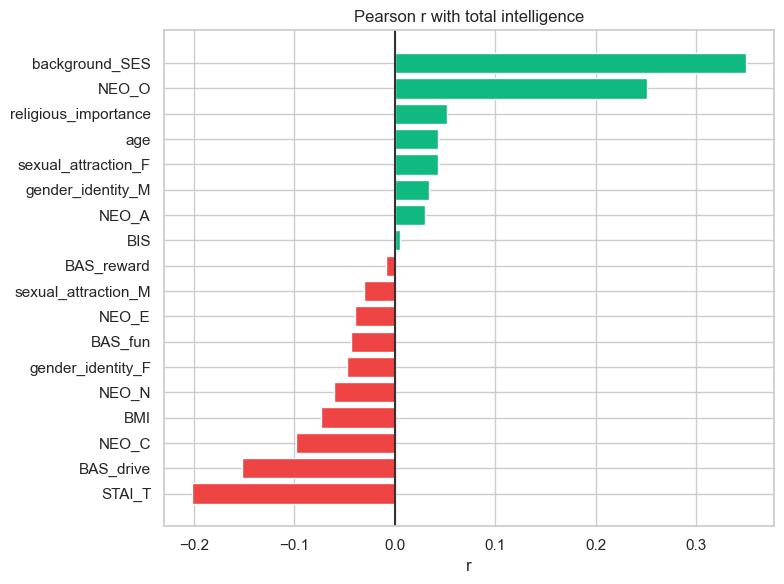

In [5]:
t = pd.to_numeric(df[target], errors="coerce")
rows = []
for c in num_cols:
    x = pd.to_numeric(df[c], errors="coerce")
    m = x.notna() & t.notna()
    if m.sum() > 30:
        rows.append((c, float(np.corrcoef(x[m], t[m])[0,1])))
rho = pd.DataFrame(rows, columns=["feature","r"]).sort_values("r")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(rho["feature"], rho["r"], color=["#ef4444" if v<0 else "#10b981" for v in rho["r"]])
ax.axvline(0, color="#333"); ax.set(title="Pearson r with total intelligence", xlabel="r")
plt.tight_layout(); plt.show()

Correlations with intelligence are individually weak (education and openness are the
usual positive signals, consistent with the literature). This is why the engine is
asked to recover the *ranking* of participants rather than exact scores, and why
adding brain modalities in later tiers is worth testing.